# 07 — Topic Modeling with TF-IDF and NMF

## Purpose

Topic modeling identifies the main recurring subjects discussed in the
developer posts.

It answers:

> What are developers talking about when they discuss AI tools, sentiment,
> stress, frustration, relief, trust, productivity, or job security?

This notebook uses:

- **TF-IDF** to represent important words and word pairs;
- **Non-negative Matrix Factorization (NMF)** to discover latent topics;
- representative texts to interpret each topic;
- platform, AI-tool, sentiment, stress, emotion, and temporal comparisons.

## Important distinction

- Sentiment analysis identifies polarity.
- Stress analysis identifies emotional signals.
- Topic modeling identifies the subject or context.

## Preferred input

`data/results/emotions/stress_emotion_predictions.jsonl`

## Main outputs

`data/results/topics/topic_assignments.jsonl`

`data/results/topics/topic_assignments.csv`


## 1. Required packages

Install the required package when necessary:

```bash
pip install scikit-learn
```


In [1]:
from pathlib import Path
import ast
import json
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)

warnings.filterwarnings("ignore")


def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Run the notebook from the project root "
        "or from the notebooks folder."
    )


PROJECT_ROOT = find_project_root()

EMOTION_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "emotions"
    / "stress_emotion_predictions.jsonl"
)

SENTIMENT_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "sentiment"
    / "sentiment_predictions.jsonl"
)

ANALYSIS_READY_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "analysis_ready_posts.jsonl"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "topics"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "topics"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Topic results:", RESULTS_DIR)
print("Topic figures:", FIGURE_DIR)


Project root: /home/rei/Desktop/internship/AI-Developer-Sentiment
Topic results: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/topics
Topic figures: /home/rei/Desktop/internship/AI-Developer-Sentiment/figures/topics


## 2. Load the best available dataset

Input priority:

1. stress and emotion predictions;
2. sentiment predictions;
3. analysis-ready dataset.


In [2]:
if EMOTION_PATH.exists():
    INPUT_PATH = EMOTION_PATH
    INPUT_DESCRIPTION = "Stress and emotion predictions"
elif SENTIMENT_PATH.exists():
    INPUT_PATH = SENTIMENT_PATH
    INPUT_DESCRIPTION = "Sentiment predictions"
elif ANALYSIS_READY_PATH.exists():
    INPUT_PATH = ANALYSIS_READY_PATH
    INPUT_DESCRIPTION = "Analysis-ready dataset"
else:
    raise FileNotFoundError(
        "No suitable input dataset was found."
    )

df = pd.read_json(
    INPUT_PATH,
    lines=True,
)

print("Input type:", INPUT_DESCRIPTION)
print("Input file:", INPUT_PATH)
print(f"Loaded records: {len(df):,}")
print(f"Columns: {len(df.columns)}")

display(df.head(5))


Input type: Stress and emotion predictions
Input file: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/emotions/stress_emotion_predictions.jsonl
Loaded records: 2,666
Columns: 73


,record_id,source_id,source,platform,community,created_at_utc,date_known,is_recent_2025_plus,title_raw,body_raw,...,stress_signal,stress_intensity,stress_intensity_score,primary_emotion,detected_emotions,stress_causes,stress_evidence,stress_detection_confidence,negative_emotion_hit_count,relief_hit_count
0,huggingface_uit-sentiment-dataset-reddit-2000-...,1kby1en,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01T02:22:03+00:00,True,True,,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,...,False,None,0,No clear emotion,[],[],[],Low,0,0
1,huggingface_uit-sentiment-dataset-reddit-2000-...,1kbym1e,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,OpenAI,2025-05-01T02:52:48+00:00,True,True,,current llms still suck I am using the top mod...,...,False,None,0,No clear emotion,[],[],[],Low,0,0
2,huggingface_uit-sentiment-dataset-reddit-2000-...,1kchgyo,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01T19:33:44+00:00,True,True,,Anthropic claims chips are smuggled as prosthe...,...,False,None,0,No clear emotion,[],[],[],Low,0,0
3,huggingface_uit-sentiment-dataset-reddit-2000-...,1kd9kcf,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,singularity,2025-05-02T19:28:21+00:00,True,True,,"I don't know why but being called a ""Human"" by...",...,False,None,0,No clear emotion,[],[],[],Low,0,0
4,huggingface_uit-sentiment-dataset-reddit-2000-...,1kdqcjk,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-03T11:00:49+00:00,True,True,,Teaching LLMs to use tools with RL! Successful...,...,False,None,0,No clear emotion,[],"[Cost and access, Learning and skill pressure,...",[],Low,0,0


## 3. Validate and normalize fields

The model uses `text_clean_lexical`.

This text version is preferred because it is already prepared for lexical
analysis and topic modeling.


In [3]:
required_columns = [
    "record_id",
    "platform",
    "text_clean_lexical",
]

missing_required = [
    column for column in required_columns
    if column not in df.columns
]

if missing_required:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_required)
    )

if df["record_id"].isna().any():
    raise ValueError("Some records have no record_id.")

if df["record_id"].duplicated().any():
    raise ValueError("Duplicate record_id values were found.")

df["text_clean_lexical"] = (
    df["text_clean_lexical"]
    .fillna("")
    .astype(str)
    .str.strip()
)

if df["text_clean_lexical"].eq("").any():
    raise ValueError(
        "Some records have empty text_clean_lexical values."
    )


def ensure_list(value):
    if isinstance(value, list):
        return value

    if value is None:
        return []

    try:
        if pd.isna(value):
            return []
    except (TypeError, ValueError):
        pass

    if isinstance(value, str):
        value = value.strip()

        if not value or value.lower() in {
            "nan", "none", "null", "[]"
        }:
            return []

        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            pass

        return [value]

    return [value]


for column in [
    "ai_tools",
    "research_themes",
    "detected_emotions",
    "stress_causes",
    "stress_evidence",
]:
    if column in df.columns:
        df[column] = df[column].map(ensure_list)
    else:
        df[column] = [[] for _ in range(len(df))]

if "created_at_utc" in df.columns:
    df["created_at_utc"] = pd.to_datetime(
        df["created_at_utc"],
        errors="coerce",
        utc=True,
    )
else:
    df["created_at_utc"] = pd.NaT

if "transformer_label" in df.columns:
    df["selected_sentiment_label"] = (
        df["transformer_label"]
    )
elif "vader_label" in df.columns:
    df["selected_sentiment_label"] = (
        df["vader_label"]
    )
elif "selected_sentiment_label" not in df.columns:
    df["selected_sentiment_label"] = "Unknown"

if "stress_direction" not in df.columns:
    df["stress_direction"] = "Unavailable"

if "primary_emotion" not in df.columns:
    df["primary_emotion"] = "Unavailable"

print("Validation and normalization completed.")


Validation and normalization completed.


## 4. Configure the topic-modeling experiment

The notebook tests several topic counts.

The final number is selected automatically using:

- lower normalized reconstruction error;
- higher topic diversity.

The result is still provisional. Topic interpretability must be checked using
keywords and representative documents.


In [4]:
RANDOM_STATE = 42

MIN_TOPICS = 4
MAX_TOPICS = 10

TOP_WORDS_FOR_EVALUATION = 12
TOP_WORDS_FOR_REPORTING = 15
REPRESENTATIVE_DOCUMENTS_PER_TOPIC = 8

MAX_FEATURES = 8000
MIN_DOCUMENT_FREQUENCY = 5
MAX_DOCUMENT_FREQUENCY = 0.85

# Set a number here to override automatic selection.
FORCED_NUMBER_OF_TOPICS = None

print(
    "Candidate topic counts:",
    list(range(MIN_TOPICS, MAX_TOPICS + 1)),
)


Candidate topic counts: [4, 5, 6, 7, 8, 9, 10]


## 5. Define domain-specific stopwords

Generic project words can dominate the topics without adding meaning.

The notebook removes common terms such as `ai`, `tool`, `model`, and `code`
only when they are too general for interpretation.


In [5]:
DOMAIN_STOPWORDS = {
    "ai",
    "artificial",
    "intelligence",
    "tool",
    "tools",
    "model",
    "models",
    "llm",
    "llms",
    "use",
    "using",
    "used",
    "user",
    "users",
    "thing",
    "things",
    "like",
    "just",
    "really",
    "make",
    "makes",
    "made",
    "way",
    "good",
    "new",
    "work",
    "works",
    "working",
    "code",
    "coding",
    "developer",
    "developers",
    "development",
    "software",
    "post",
    "question",
    "issue",
    "github",
    "reddit",
    "stackoverflow",
    "hacker",
    "news",
    "chatgpt",
    "gpt",
    "openai",
}

STOPWORDS = sorted(
    set(ENGLISH_STOP_WORDS)
    | DOMAIN_STOPWORDS
)

print("Total stopwords:", len(STOPWORDS))


Total stopwords: 362


## 6. Create TF-IDF features

The vectorizer uses:

- unigrams;
- bigrams;
- English and domain-specific stopwords;
- minimum and maximum document-frequency filtering.


In [6]:
vectorizer = TfidfVectorizer(
    stop_words=STOPWORDS,
    ngram_range=(1, 2),
    min_df=MIN_DOCUMENT_FREQUENCY,
    max_df=MAX_DOCUMENT_FREQUENCY,
    max_features=MAX_FEATURES,
    sublinear_tf=True,
    strip_accents="unicode",
)

tfidf_matrix = vectorizer.fit_transform(
    df["text_clean_lexical"]
)

feature_names = np.array(
    vectorizer.get_feature_names_out()
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size:", len(feature_names))

if tfidf_matrix.shape[1] < 20:
    raise ValueError(
        "Too few TF-IDF features were created. "
        "Reduce min_df or inspect text_clean_lexical."
    )


TF-IDF matrix shape: (2666, 7608)
Vocabulary size: 7608


## 7. Inspect the most frequent TF-IDF features

This helps identify remaining generic terms before topic modeling.


In [7]:
global_feature_scores = np.asarray(
    tfidf_matrix.sum(axis=0)
).ravel()

top_global_indices = (
    global_feature_scores
    .argsort()[::-1][:30]
)

top_global_features = pd.DataFrame({
    "feature": feature_names[top_global_indices],
    "tfidf_sum": (
        global_feature_scores[top_global_indices]
    ),
})

display(top_global_features)

top_global_features.to_csv(
    RESULTS_DIR / "top_global_tfidf_features.csv",
    index=False,
)


,feature,tfidf_sum
0,gemini,72.036281
1,claude,62.818253
2,anthropic,53.289661
3,llama,40.683607
4,google,32.772257
5,pro,31.583715
6,open,31.107531
7,ve,30.860847
8,local,29.638047
9,run,29.579050


## 8. Define topic-evaluation functions

### Reconstruction error

Measures how closely the NMF topic representation reconstructs the TF-IDF
matrix. Lower is better.

### Topic diversity

Measures how many unique words appear across the top words of all topics.
Higher is better.


In [8]:
def get_top_term_indices(
    components,
    top_n,
):
    return np.argsort(
        components,
        axis=1,
    )[:, ::-1][:, :top_n]


def calculate_topic_diversity(
    components,
    top_n,
):
    top_indices = get_top_term_indices(
        components,
        top_n,
    )

    flattened = top_indices.ravel()

    return (
        len(np.unique(flattened))
        / len(flattened)
    )


def minmax_scale(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            np.ones(len(series)),
            index=series.index,
        )

    return (
        (series - minimum)
        / (maximum - minimum)
    )


## 9. Test several numbers of topics

This cell fits one NMF model for every candidate topic count.


In [9]:
candidate_results = []
candidate_models = {}

for number_of_topics in range(
    MIN_TOPICS,
    MAX_TOPICS + 1,
):
    model = NMF(
        n_components=number_of_topics,
        init="nndsvda",
        random_state=RANDOM_STATE,
        max_iter=500,
        solver="cd",
        beta_loss="frobenius",
        l1_ratio=0.0,
    )

    document_topic_matrix = (
        model.fit_transform(tfidf_matrix)
    )

    reconstruction_error = float(
        model.reconstruction_err_
    )

    topic_diversity = float(
        calculate_topic_diversity(
            model.components_,
            TOP_WORDS_FOR_EVALUATION,
        )
    )

    candidate_results.append({
        "number_of_topics": number_of_topics,
        "reconstruction_error": reconstruction_error,
        "topic_diversity": topic_diversity,
        "iterations": int(model.n_iter_),
    })

    candidate_models[
        number_of_topics
    ] = {
        "model": model,
        "document_topic_matrix": (
            document_topic_matrix
        ),
    }

candidate_evaluation = pd.DataFrame(
    candidate_results
)

candidate_evaluation[
    "inverse_error_score"
] = 1 - minmax_scale(
    candidate_evaluation[
        "reconstruction_error"
    ]
)

candidate_evaluation[
    "diversity_score"
] = minmax_scale(
    candidate_evaluation[
        "topic_diversity"
    ]
)

candidate_evaluation[
    "combined_quality_score"
] = (
    0.70
    * candidate_evaluation[
        "inverse_error_score"
    ]
    + 0.30
    * candidate_evaluation[
        "diversity_score"
    ]
)

candidate_evaluation = (
    candidate_evaluation
    .sort_values("number_of_topics")
    .reset_index(drop=True)
)

display(
    candidate_evaluation.round(4)
)

candidate_evaluation.to_csv(
    RESULTS_DIR
    / "topic_count_evaluation.csv",
    index=False,
)


,number_of_topics,reconstruction_error,topic_diversity,iterations,inverse_error_score,diversity_score,combined_quality_score
0,4,50.5115,1.0000,17,0.0000,1.0000,0.3000
1,5,50.3606,1.0000,30,0.2334,1.0000,0.4634
2,6,50.2580,0.9583,57,0.3919,0.0000,0.2744
3,7,50.1537,0.9643,55,0.5532,0.1429,0.4301
4,8,50.0544,0.9688,125,0.7068,0.2500,0.5697
5,9,49.9568,0.9630,123,0.8576,0.1111,0.6337
6,10,49.8647,0.9583,103,1.0000,0.0000,0.7000


## 10. Visualize topic-count evaluation


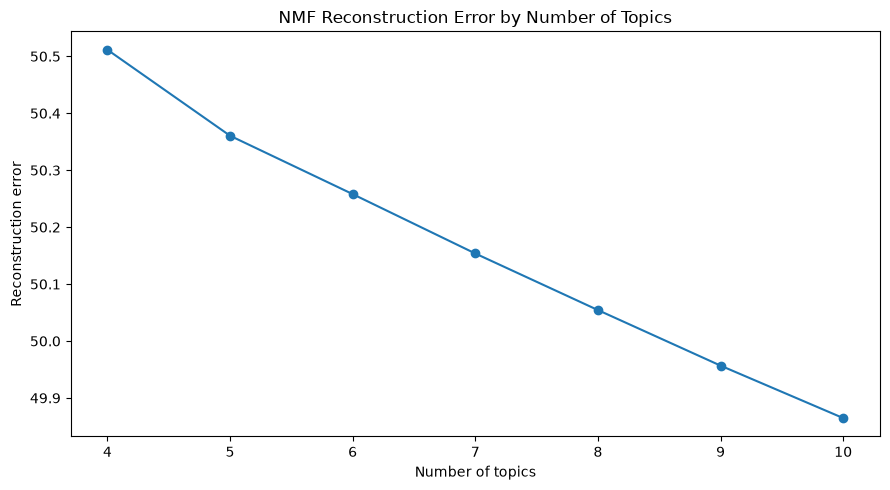

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(
    candidate_evaluation[
        "number_of_topics"
    ],
    candidate_evaluation[
        "reconstruction_error"
    ],
    marker="o",
)

plt.title("NMF Reconstruction Error by Number of Topics")
plt.xlabel("Number of topics")
plt.ylabel("Reconstruction error")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "topic_count_reconstruction_error.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


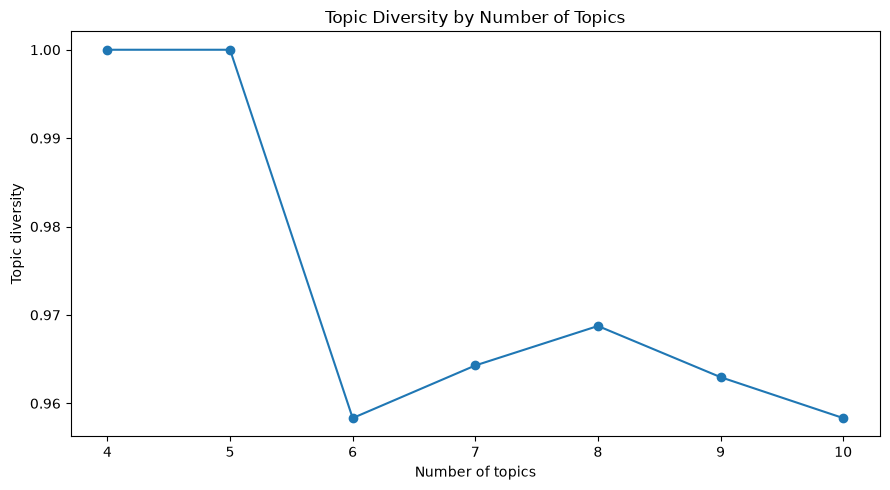

In [11]:
plt.figure(figsize=(9, 5))

plt.plot(
    candidate_evaluation[
        "number_of_topics"
    ],
    candidate_evaluation[
        "topic_diversity"
    ],
    marker="o",
)

plt.title("Topic Diversity by Number of Topics")
plt.xlabel("Number of topics")
plt.ylabel("Topic diversity")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "topic_count_diversity.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


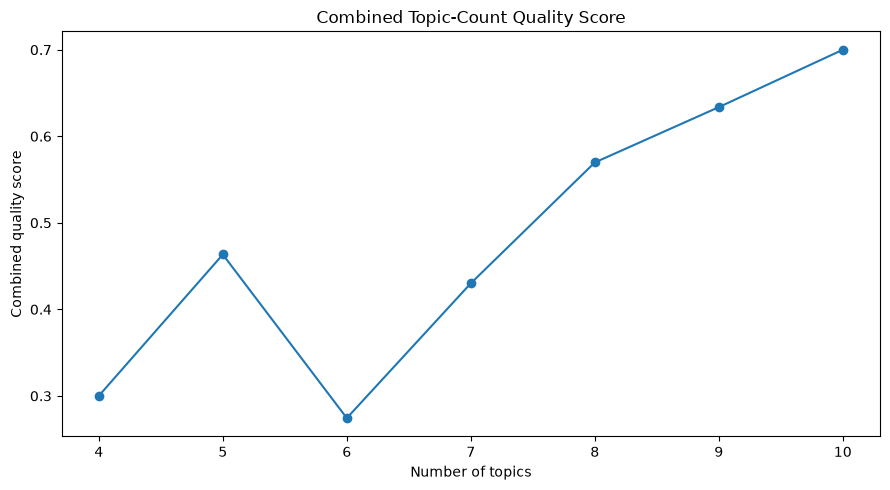

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    candidate_evaluation[
        "number_of_topics"
    ],
    candidate_evaluation[
        "combined_quality_score"
    ],
    marker="o",
)

plt.title("Combined Topic-Count Quality Score")
plt.xlabel("Number of topics")
plt.ylabel("Combined quality score")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "topic_count_combined_score.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 11. Select the final number of topics

When `FORCED_NUMBER_OF_TOPICS` is not set, the notebook selects the highest
combined quality score.


In [13]:
if FORCED_NUMBER_OF_TOPICS is not None:
    if FORCED_NUMBER_OF_TOPICS not in candidate_models:
        raise ValueError(
            "FORCED_NUMBER_OF_TOPICS must be within "
            f"{MIN_TOPICS} and {MAX_TOPICS}."
        )

    SELECTED_NUMBER_OF_TOPICS = (
        FORCED_NUMBER_OF_TOPICS
    )

    selection_method = "Manually forced"
else:
    best_candidate = (
        candidate_evaluation
        .sort_values(
            "combined_quality_score",
            ascending=False,
        )
        .iloc[0]
    )

    SELECTED_NUMBER_OF_TOPICS = int(
        best_candidate[
            "number_of_topics"
        ]
    )

    selection_method = (
        "Highest combined reconstruction-diversity score"
    )

print(
    "Selected number of topics:",
    SELECTED_NUMBER_OF_TOPICS,
)

print("Selection method:", selection_method)


Selected number of topics: 10
Selection method: Highest combined reconstruction-diversity score


## 12. Retrieve the selected NMF model


In [14]:
selected_bundle = candidate_models[
    SELECTED_NUMBER_OF_TOPICS
]

nmf_model = selected_bundle["model"]

document_topic_matrix = (
    selected_bundle[
        "document_topic_matrix"
    ]
)

print(
    "Document-topic matrix shape:",
    document_topic_matrix.shape,
)

print(
    "Topic-term matrix shape:",
    nmf_model.components_.shape,
)


Document-topic matrix shape: (2666, 10)
Topic-term matrix shape: (10, 7608)


## 13. Extract top keywords for every topic


In [15]:
topic_keyword_rows = []

for topic_id, topic_weights in enumerate(
    nmf_model.components_
):
    top_indices = (
        topic_weights
        .argsort()[::-1][
            :TOP_WORDS_FOR_REPORTING
        ]
    )

    top_terms = feature_names[top_indices]
    top_weights = topic_weights[top_indices]

    for rank, (
        term,
        weight,
    ) in enumerate(
        zip(
            top_terms,
            top_weights,
        ),
        start=1,
    ):
        topic_keyword_rows.append({
            "topic_id": topic_id,
            "rank": rank,
            "term": term,
            "weight": float(weight),
        })

topic_keywords = pd.DataFrame(
    topic_keyword_rows
)

display(
    topic_keywords.head(
        TOP_WORDS_FOR_REPORTING * 3
    )
)

topic_keywords.to_csv(
    RESULTS_DIR / "topic_keywords.csv",
    index=False,
)


,topic_id,rank,term,weight
0,0,1,ve,0.455503
1,0,2,don,0.424990
2,0,3,know,0.415423
3,0,4,think,0.384382
4,0,5,people,0.363697
5,0,6,want,0.354905
6,0,7,time,0.337638
7,0,8,better,0.332449
8,0,9,need,0.311218
9,0,10,right,0.287289


## 14. Create provisional topic names

The notebook automatically joins the top three terms.

These names are provisional and should be replaced with human-readable names
after reviewing representative documents.


In [16]:
topic_name_rows = []

for topic_id in range(
    SELECTED_NUMBER_OF_TOPICS
):
    terms = (
        topic_keywords.loc[
            topic_keywords[
                "topic_id"
            ].eq(topic_id)
        ]
        .sort_values("rank")
        .head(3)["term"]
        .tolist()
    )

    provisional_name = " / ".join(
        term.title()
        for term in terms
    )

    topic_name_rows.append({
        "topic_id": topic_id,
        "provisional_topic_name": (
            provisional_name
        ),
    })

topic_names = pd.DataFrame(
    topic_name_rows
)

display(topic_names)

topic_names.to_csv(
    RESULTS_DIR
    / "provisional_topic_names.csv",
    index=False,
)

TOPIC_NAME_MAP = dict(
    zip(
        topic_names["topic_id"],
        topic_names[
            "provisional_topic_name"
        ],
    )
)


,topic_id,provisional_topic_name
0,0,Ve / Don / Know
1,1,Gemini Pro / Pro / Gemini
2,2,Enabled / Disabled / Ms
3,3,Anthropic / Claude Anthropic / Anthropic Claude
4,4,Llama / Cpp / Llama Cpp
5,5,Claude / Sonnet / Opus
6,6,Output Mismatch / Mismatch / List Output
7,7,Agent / Open / Source
8,8,Gemini / Google / Flash
9,9,Removed / Engineering / Ml


## 15. Assign a dominant topic to every record

The topic confidence is calculated as:

> dominant topic weight / sum of topic weights for the document


In [17]:
dominant_topic_ids = (
    document_topic_matrix
    .argmax(axis=1)
)

dominant_topic_weights = (
    document_topic_matrix[
        np.arange(
            len(document_topic_matrix)
        ),
        dominant_topic_ids,
    ]
)

topic_weight_sums = (
    document_topic_matrix
    .sum(axis=1)
)

topic_confidence = np.divide(
    dominant_topic_weights,
    topic_weight_sums,
    out=np.zeros_like(
        dominant_topic_weights,
        dtype=float,
    ),
    where=topic_weight_sums != 0,
)

df["topic_id"] = dominant_topic_ids
df["topic_name"] = (
    df["topic_id"]
    .map(TOPIC_NAME_MAP)
)

df["topic_weight"] = (
    dominant_topic_weights
)

df["topic_confidence"] = (
    topic_confidence
)

df["topic_low_confidence"] = (
    df["topic_confidence"] < 0.35
)

display(
    df[
        [
            "record_id",
            "text_clean_lexical",
            "topic_id",
            "topic_name",
            "topic_weight",
            "topic_confidence",
            "topic_low_confidence",
        ]
    ].head(10)
)


,record_id,text_clean_lexical,topic_id,topic_name,topic_weight,topic_confidence,topic_low_confidence
0,huggingface_uit-sentiment-dataset-reddit-2000-...,shuttle 3 5 qwen3 32b finetune we are excited ...,5,Claude / Sonnet / Opus,0.051471,0.546021,False
1,huggingface_uit-sentiment-dataset-reddit-2000-...,current llms still suck i am using the top mod...,5,Claude / Sonnet / Opus,0.109298,0.636084,False
2,huggingface_uit-sentiment-dataset-reddit-2000-...,anthropic claims chips are smuggled as prosthe...,3,Anthropic / Claude Anthropic / Anthropic Claude,0.118519,0.868990,False
3,huggingface_uit-sentiment-dataset-reddit-2000-...,i don't know why but being called a human by t...,5,Claude / Sonnet / Opus,0.097911,0.669271,False
4,huggingface_uit-sentiment-dataset-reddit-2000-...,teaching llms to use tools with rl successfull...,0,Ve / Don / Know,0.039364,0.390517,False
5,huggingface_uit-sentiment-dataset-reddit-2000-...,qwen3 235b a22b no thinking seemingly outperfo...,5,Claude / Sonnet / Opus,0.056863,0.466805,False
6,huggingface_uit-sentiment-dataset-reddit-2000-...,claude max or augmentcode hi guys i want to ma...,5,Claude / Sonnet / Opus,0.088383,0.584912,False
7,huggingface_uit-sentiment-dataset-reddit-2000-...,qwq 32b vs qwen 3 32b vs glm 4 32b html coding...,5,Claude / Sonnet / Opus,0.029336,0.269929,True
8,huggingface_uit-sentiment-dataset-reddit-2000-...,mcp task scheduler schedule reminders api call...,5,Claude / Sonnet / Opus,0.062467,0.597419,False
9,huggingface_uit-sentiment-dataset-reddit-2000-...,this is how i ll build agi hello community i h...,0,Ve / Don / Know,0.097682,0.655762,False


## 16. Validate topic assignments


In [18]:
topic_validation = {
    "records": len(df),
    "selected_number_of_topics": (
        SELECTED_NUMBER_OF_TOPICS
    ),
    "missing_topic_ids": int(
        df["topic_id"].isna().sum()
    ),
    "missing_topic_names": int(
        df["topic_name"].isna().sum()
    ),
    "minimum_topic_confidence": round(
        float(
            df["topic_confidence"].min()
        ),
        6,
    ),
    "maximum_topic_confidence": round(
        float(
            df["topic_confidence"].max()
        ),
        6,
    ),
    "low_confidence_assignments": int(
        df["topic_low_confidence"].sum()
    ),
}

topic_validation_table = (
    pd.Series(
        topic_validation,
        name="value",
    )
    .rename_axis("check")
    .reset_index()
)

display(topic_validation_table)

topic_validation_table.to_csv(
    RESULTS_DIR / "topic_validation.csv",
    index=False,
)


,check,value
0,records,2666.0
1,selected_number_of_topics,10.0
2,missing_topic_ids,0.0
3,missing_topic_names,0.0
4,minimum_topic_confidence,0.0
5,maximum_topic_confidence,1.0
6,low_confidence_assignments,124.0


## 17. Topic distribution


,topic_id,topic_name,records,percentage
0,0,Ve / Don / Know,760,28.51
7,7,Agent / Open / Source,526,19.73
4,4,Llama / Cpp / Llama Cpp,334,12.53
8,8,Gemini / Google / Flash,275,10.32
5,5,Claude / Sonnet / Opus,271,10.17
3,3,Anthropic / Claude Anthropic / Anthropic Claude,247,9.26
1,1,Gemini Pro / Pro / Gemini,117,4.39
9,9,Removed / Engineering / Ml,68,2.55
2,2,Enabled / Disabled / Ms,51,1.91
6,6,Output Mismatch / Mismatch / List Output,17,0.64


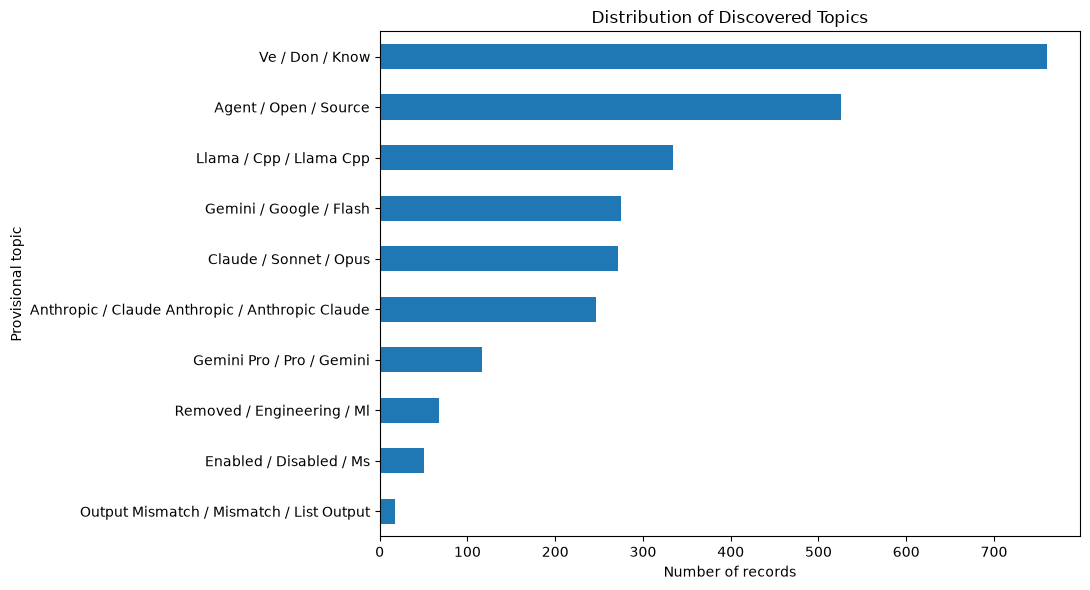

In [19]:
topic_distribution = (
    df.groupby(
        ["topic_id", "topic_name"]
    )
    .size()
    .reset_index(name="records")
    .sort_values(
        "records",
        ascending=False,
    )
)

topic_distribution["percentage"] = (
    topic_distribution["records"]
    / len(df)
    * 100
).round(2)

display(topic_distribution)

topic_distribution.to_csv(
    RESULTS_DIR
    / "topic_distribution.csv",
    index=False,
)

plot_data = (
    topic_distribution
    .sort_values("records")
    .set_index("topic_name")[
        "records"
    ]
)

plt.figure(figsize=(11, 6))

plot_data.plot(kind="barh")

plt.title("Distribution of Discovered Topics")
plt.xlabel("Number of records")
plt.ylabel("Provisional topic")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "topic_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 18. Representative documents for every topic

These texts are essential for interpreting and renaming the topics.


In [20]:
representative_rows = []

for topic_id in range(
    SELECTED_NUMBER_OF_TOPICS
):
    topic_scores = (
        document_topic_matrix[
            :,
            topic_id,
        ]
    )

    representative_indices = (
        topic_scores
        .argsort()[::-1][
            :REPRESENTATIVE_DOCUMENTS_PER_TOPIC
        ]
    )

    for rank, row_index in enumerate(
        representative_indices,
        start=1,
    ):
        row = df.iloc[row_index]

        representative_rows.append({
            "topic_id": topic_id,
            "topic_name": (
                TOPIC_NAME_MAP[topic_id]
            ),
            "representative_rank": rank,
            "record_id": row[
                "record_id"
            ],
            "platform": row[
                "platform"
            ],
            "topic_weight": float(
                topic_scores[
                    row_index
                ]
            ),
            "full_text_raw": row.get(
                "full_text_raw",
                "",
            ),
            "text_clean_basic": row.get(
                "text_clean_basic",
                "",
            ),
            "selected_sentiment_label": row.get(
                "selected_sentiment_label",
                "Unknown",
            ),
            "stress_direction": row.get(
                "stress_direction",
                "Unavailable",
            ),
            "primary_emotion": row.get(
                "primary_emotion",
                "Unavailable",
            ),
        })

representative_documents = pd.DataFrame(
    representative_rows
)

representative_documents.to_csv(
    RESULTS_DIR
    / "topic_representative_documents.csv",
    index=False,
)

for topic_id in range(
    SELECTED_NUMBER_OF_TOPICS
):
    print(
        "\nTopic",
        topic_id,
        "-",
        TOPIC_NAME_MAP[topic_id],
    )

    keywords = (
        topic_keywords.loc[
            topic_keywords[
                "topic_id"
            ].eq(topic_id)
        ]
        .sort_values("rank")
        .head(10)["term"]
        .tolist()
    )

    print("Keywords:", keywords)

    display(
        representative_documents.loc[
            representative_documents[
                "topic_id"
            ].eq(topic_id)
        ][
            [
                "representative_rank",
                "platform",
                "text_clean_basic",
                "selected_sentiment_label",
                "stress_direction",
                "primary_emotion",
            ]
        ]
    )



Topic 0 - Ve / Don / Know
Keywords: ['ve', 'don', 'know', 'think', 'people', 'want', 'time', 'better', 'need', 'right']


,representative_rank,platform,text_clean_basic,selected_sentiment_label,stress_direction,primary_emotion
0,1,Stack Overflow,How can I avoid using LLMs as a software devel...,Positive,Increased stress or distress,Stress or anxiety
1,2,Reddit,Request for memetic content # The Seed Phrase ...,Neutral,Increased stress or distress,Stress or anxiety
2,3,Reddit,"AGI & ASI : A chain of ""MULTIMODAL-TOKEN"" Stre...",Neutral,Increased stress or distress,Stress or anxiety
3,4,Reddit,Reson: Teaching AI to think about Its own thin...,Neutral,Increased stress or distress,Distrust or uncertainty
4,5,Reddit,Don’t call it ChatGPT if you don’t want a conv...,Negative,Increased stress or distress,Stress or anxiety
5,6,Reddit,I built a GPT bot that my colleagues love and ...,Positive,Increased stress or distress,Frustration
6,7,Reddit,"'Sycophancy' and Emotional ""Intellect"" are 2 d...",Negative,Increased stress or distress,Distrust or uncertainty
7,8,Reddit,What are the true limitations of LLM. Everyone...,Neutral,Increased stress or distress,Distrust or uncertainty



Topic 1 - Gemini Pro / Pro / Gemini
Keywords: ['gemini pro', 'pro', 'gemini', 'preview', '06', '05', 'pro preview', '05 06', 'update', 'discount']


,representative_rank,platform,text_clean_basic,selected_sentiment_label,stress_direction,primary_emotion
8,1,Reddit,Gemini 3.0 Pro spotted,Neutral,No clear stress signal,No clear emotion
9,2,Reddit,Preview of Gemini 3.0 Pro [,Neutral,No clear stress signal,No clear emotion
10,3,Reddit,@Chetaslua UBUNTU Gemini 3.0 Pro - ONE SHOTTED,Neutral,No clear stress signal,No clear emotion
11,4,Reddit,Today's gemini 2.5 pro update,Neutral,No clear stress signal,No clear emotion
12,5,Reddit,New Version of Gemini 2.5 Pro: gemini-2.5-pro-...,Neutral,No clear stress signal,No clear emotion
13,6,Reddit,Gemini 2.5 Pro latest update is now in preview...,Neutral,No clear stress signal,No clear emotion
14,7,Reddit,Gemini 2.5 Pro GA benchmarks,Neutral,No clear stress signal,No clear emotion
15,8,Reddit,Aider Polygot of Gemini 2.5 Pro 05-06,Neutral,No clear stress signal,No clear emotion



Topic 2 - Enabled / Disabled / Ms
Keywords: ['enabled', 'disabled', 'ms', 'cp', 'cls', 'vscode', 'cp cls', 'version', 'driver', 'vendor']


...

,representative_rank,platform,text_clean_basic,selected_sentiment_label,stress_direction,primary_emotion
56,1,GitHub Issues,Agents window: chat input silently dropped in ...,Neutral,Increased stress or distress,Frustration
57,2,GitHub Issues,Review Agent (Code Review - Uncommitted Change...,Neutral,Increased stress or distress,Distrust or uncertainty
58,3,GitHub Issues,Persistent HTTP 503 error from tool_search dur...,Neutral,No clear stress signal,No clear emotion
59,4,GitHub Issues,Agents Window over SSH: BYOK unsupported + age...,Neutral,No clear stress signal,No clear emotion
60,5,GitHub Issues,Copilot Chat startup force-opens historical re...,Neutral,No clear stress signal,No clear emotion
61,6,GitHub Issues,"When using dev containers, copilot uses `~/.co...",Neutral,No clear stress signal,No clear emotion
62,7,GitHub Issues,Qwen models from OpenCode Go subscription stop...,Neutral,No clear stress signal,No clear emotion
63,8,GitHub Issues,Agent Host: GitHub MCP initial-auth token reus...,Neutral,No clear stress signal,No clear emotion



Topic 8 - Gemini / Google / Flash
Keywords: ['gemini', 'google', 'flash', 'gemini flash', 'google gemini', 'image', 'nano', 'banana', 'gemini cli', 'nano banana']


,representative_rank,platform,text_clean_basic,selected_sentiment_label,stress_direction,primary_emotion
64,1,Reddit,Gemini is now on WearOS!,Neutral,No clear stress signal,No clear emotion
65,2,Reddit,Gemini 2.5 Flash replace Gemini 2.0 Flash as t...,Neutral,No clear stress signal,No clear emotion
66,3,Reddit,langchain4j google-ai-gemini I am seeking help...,Neutral,No clear stress signal,No clear emotion
67,4,Reddit,Google Gemini AI will call 911 even when you t...,Neutral,No clear stress signal,No clear emotion
68,5,Hacker News,"Gemini 3.6 Flash, 3.5 Flash-Lite, and 3.5 Flas...",Neutral,No clear stress signal,No clear emotion
69,6,Reddit,Gemini 3 Possibly Flash 3.0,Neutral,No clear stress signal,No clear emotion
70,7,Reddit,New Gemini Model Made With The Best First Impr...,Positive,No clear stress signal,No clear emotion
71,8,Reddit,"Google is now officially calling ""Gemini 2.5 F...",Neutral,No clear stress signal,No clear emotion



Topic 9 - Removed / Engineering / Ml
Keywords: ['removed', 'engineering', 'ml', 'learn', 'builder', 'guess', 'data', 'portfolio', 'transition', 'generated']


,representative_rank,platform,text_clean_basic,selected_sentiment_label,stress_direction,primary_emotion
72,1,Reddit,The 5 Phases of Craftship (Why AI Amplifies Wh...,Neutral,No clear stress signal,No clear emotion
73,2,Reddit,Where to learn more about AI? [removed],Neutral,No clear stress signal,No clear emotion
74,3,Reddit,AI interviewer with exercise? [removed],Neutral,No clear stress signal,No clear emotion
75,4,Reddit,How AI Will Change Engineering in Five Years [...,Neutral,No clear stress signal,No clear emotion
76,5,Reddit,is dreamhost good for small ecom or should I j...,Neutral,No clear stress signal,No clear emotion
77,6,Reddit,Ai Automation or Data analysis [removed],Neutral,No clear stress signal,No clear emotion
78,7,Reddit,Artificial Intelligence explained in an intere...,Positive,No clear stress signal,No clear emotion
79,8,Reddit,Guess the AI model from its embedding structur...,Neutral,No clear stress signal,No clear emotion


## 19. Create a topic-summary table


In [21]:
topic_summary_rows = []

for topic_id in range(
    SELECTED_NUMBER_OF_TOPICS
):
    topic_subset = df.loc[
        df["topic_id"].eq(topic_id)
    ]

    top_terms = (
        topic_keywords.loc[
            topic_keywords[
                "topic_id"
            ].eq(topic_id)
        ]
        .sort_values("rank")
        .head(10)["term"]
        .tolist()
    )

    dominant_platform = (
        topic_subset["platform"]
        .value_counts()
        .index[0]
        if not topic_subset.empty
        else None
    )

    dominant_sentiment = (
        topic_subset[
            "selected_sentiment_label"
        ]
        .value_counts()
        .index[0]
        if not topic_subset.empty
        else None
    )

    dominant_stress_direction = (
        topic_subset[
            "stress_direction"
        ]
        .value_counts()
        .index[0]
        if not topic_subset.empty
        else None
    )

    topic_summary_rows.append({
        "topic_id": topic_id,
        "topic_name": (
            TOPIC_NAME_MAP[topic_id]
        ),
        "records": len(topic_subset),
        "percentage": round(
            len(topic_subset)
            / len(df)
            * 100,
            2,
        ),
        "top_keywords": ", ".join(
            top_terms
        ),
        "dominant_platform": (
            dominant_platform
        ),
        "dominant_sentiment": (
            dominant_sentiment
        ),
        "dominant_stress_direction": (
            dominant_stress_direction
        ),
        "mean_topic_confidence": round(
            float(
                topic_subset[
                    "topic_confidence"
                ].mean()
            ),
            4,
        )
        if not topic_subset.empty
        else None,
    })

topic_summary = pd.DataFrame(
    topic_summary_rows
)

display(topic_summary)

topic_summary.to_csv(
    RESULTS_DIR
    / "topic_summary.csv",
    index=False,
)


,topic_id,topic_name,records,percentage,top_keywords,dominant_platform,dominant_sentiment,dominant_stress_direction,mean_topic_confidence
0,0,Ve / Don / Know,760,28.51,"ve, don, know, think, people, want, time, bett...",Reddit,Neutral,No clear stress signal,0.6187
1,1,Gemini Pro / Pro / Gemini,117,4.39,"gemini pro, pro, gemini, preview, 06, 05, pro ...",Reddit,Neutral,No clear stress signal,0.6999
2,2,Enabled / Disabled / Ms,51,1.91,"enabled, disabled, ms, cp, cls, vscode, cp cls...",GitHub Issues,Neutral,No clear stress signal,0.8502
3,3,Anthropic / Claude Anthropic / Anthropic Claude,247,9.26,"anthropic, claude anthropic, anthropic claude,...",Reddit,Neutral,No clear stress signal,0.7048
4,4,Llama / Cpp / Llama Cpp,334,12.53,"llama, cpp, llama cpp, gguf, qwen3, gpu, ollam...",Reddit,Neutral,No clear stress signal,0.6658
5,5,Claude / Sonnet / Opus,271,10.17,"claude, sonnet, opus, claude sonnet, claude op...",Reddit,Neutral,No clear stress signal,0.6261
6,6,Output Mismatch / Mismatch / List Output,17,0.64,"output mismatch, mismatch, list output, output...",GitHub Issues,Neutral,No clear stress signal,0.7775
7,7,Agent / Open / Source,526,19.73,"agent, open, source, copilot, open source, cha...",Reddit,Neutral,No clear stress signal,0.5888
8,8,Gemini / Google / Flash,275,10.32,"gemini, google, flash, gemini flash, google ge...",Reddit,Neutral,No clear stress signal,0.6709
9,9,Removed / Engineering / Ml,68,2.55,"removed, engineering, ml, learn, builder, gues...",Reddit,Neutral,No clear stress signal,0.8409


## 20. Topics by platform

Percentages are calculated within each platform.


topic_name,Agent / Open / Source,Anthropic / Claude Anthropic / Anthropic Claude,Claude / Sonnet / Opus,Enabled / Disabled / Ms,Gemini / Google / Flash,Gemini Pro / Pro / Gemini,Llama / Cpp / Llama Cpp,Output Mismatch / Mismatch / List Output,Removed / Engineering / Ml,Ve / Don / Know
platform,,,,,,,,,,
GitHub Issues,176,0,0,45,0,0,4,12,0,8
Hacker News,58,14,5,1,4,0,4,1,3,50
Other social dataset,1,108,26,0,3,1,0,0,0,0
Reddit,225,125,234,5,265,115,326,4,64,670
Stack Overflow,66,0,6,0,3,1,0,0,1,32


topic_name,Agent / Open / Source,Anthropic / Claude Anthropic / Anthropic Claude,Claude / Sonnet / Opus,Enabled / Disabled / Ms,Gemini / Google / Flash,Gemini Pro / Pro / Gemini,Llama / Cpp / Llama Cpp,Output Mismatch / Mismatch / List Output,Removed / Engineering / Ml,Ve / Don / Know
platform,,,,,,,,,,
GitHub Issues,71.84,0.00,0.00,18.37,0.00,0.00,1.63,4.90,0.00,3.27
Hacker News,41.43,10.00,3.57,0.71,2.86,0.00,2.86,0.71,2.14,35.71
Other social dataset,0.72,77.70,18.71,0.00,2.16,0.72,0.00,0.00,0.00,0.00
Reddit,11.07,6.15,11.51,0.25,13.03,5.66,16.04,0.20,3.15,32.96
Stack Overflow,60.55,0.00,5.50,0.00,2.75,0.92,0.00,0.00,0.92,29.36


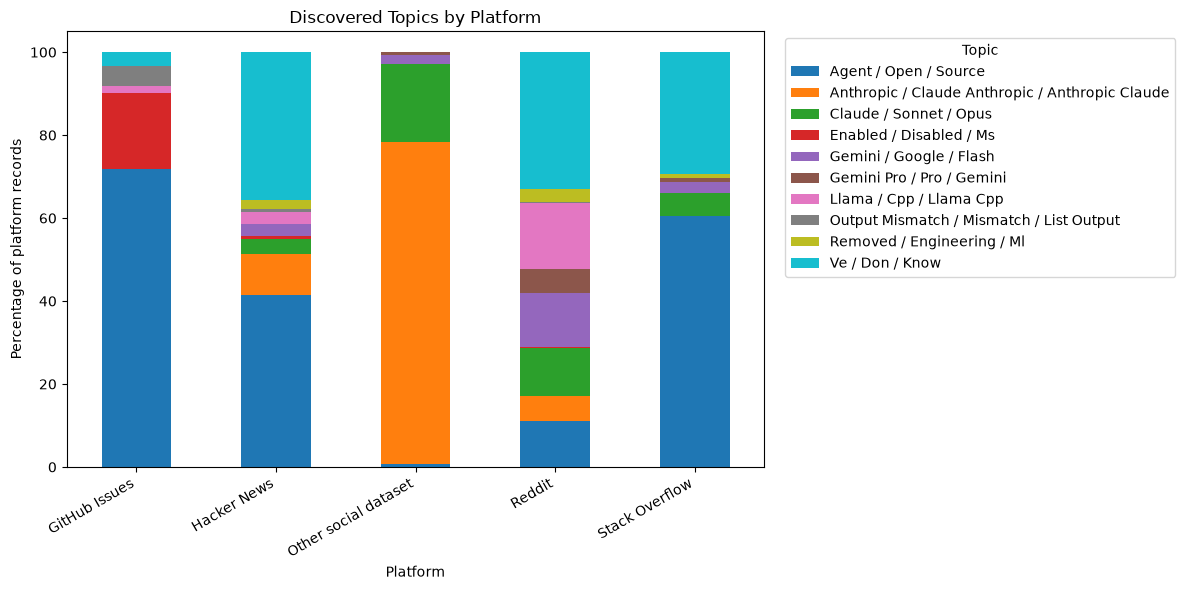

In [22]:
topics_by_platform_counts = (
    df.groupby(
        ["platform", "topic_name"]
    )
    .size()
    .unstack(fill_value=0)
)

platform_totals = (
    topics_by_platform_counts
    .sum(axis=1)
    .replace(0, np.nan)
)

topics_by_platform_percent = (
    topics_by_platform_counts
    .div(platform_totals, axis=0)
    .mul(100)
    .fillna(0)
    .round(2)
)

display(topics_by_platform_counts)
display(topics_by_platform_percent)

topics_by_platform_counts.to_csv(
    RESULTS_DIR
    / "topics_by_platform_counts.csv"
)

topics_by_platform_percent.to_csv(
    RESULTS_DIR
    / "topics_by_platform_percent.csv"
)

plt.figure(figsize=(12, 6))

topics_by_platform_percent.plot(
    kind="bar",
    stacked=True,
    ax=plt.gca(),
)

plt.title("Discovered Topics by Platform")
plt.xlabel("Platform")
plt.ylabel("Percentage of platform records")
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "topics_by_platform.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 21. Topics by AI tool

One document may mention more than one AI tool.


topic_name,Agent / Open / Source,Anthropic / Claude Anthropic / Anthropic Claude,Claude / Sonnet / Opus,Enabled / Disabled / Ms,Gemini / Google / Flash,Gemini Pro / Pro / Gemini,Llama / Cpp / Llama Cpp,Output Mismatch / Mismatch / List Output,Removed / Engineering / Ml,Ve / Don / Know
ai_tools,,,,,,,,,,
AI,20.88,15.71,6.59,1.22,7.62,3.10,5.27,1.32,5.74,32.55
Claude/Anthropic,14.52,33.43,38.58,2.72,0.61,0.15,0.15,0.00,0.15,9.68
Gemini,5.66,1.01,0.40,0.20,52.73,21.62,1.01,0.00,0.40,16.97
LLM,21.83,4.68,7.57,0.00,6.01,2.00,20.71,0.22,0.67,36.30
Llama,10.26,0.24,0.24,0.00,0.00,0.48,69.93,0.24,0.00,18.62
OpenAI,23.14,18.04,1.18,3.92,2.75,1.18,1.18,0.39,0.39,47.84
ChatGPT,15.38,3.24,1.62,3.24,0.40,1.62,0.40,0.00,0.81,73.28
GPT,21.70,1.28,2.98,1.70,2.13,1.70,5.11,0.43,0.43,62.55
GitHub Copilot,64.52,1.94,5.81,19.35,1.29,0.00,0.65,0.00,1.94,4.52


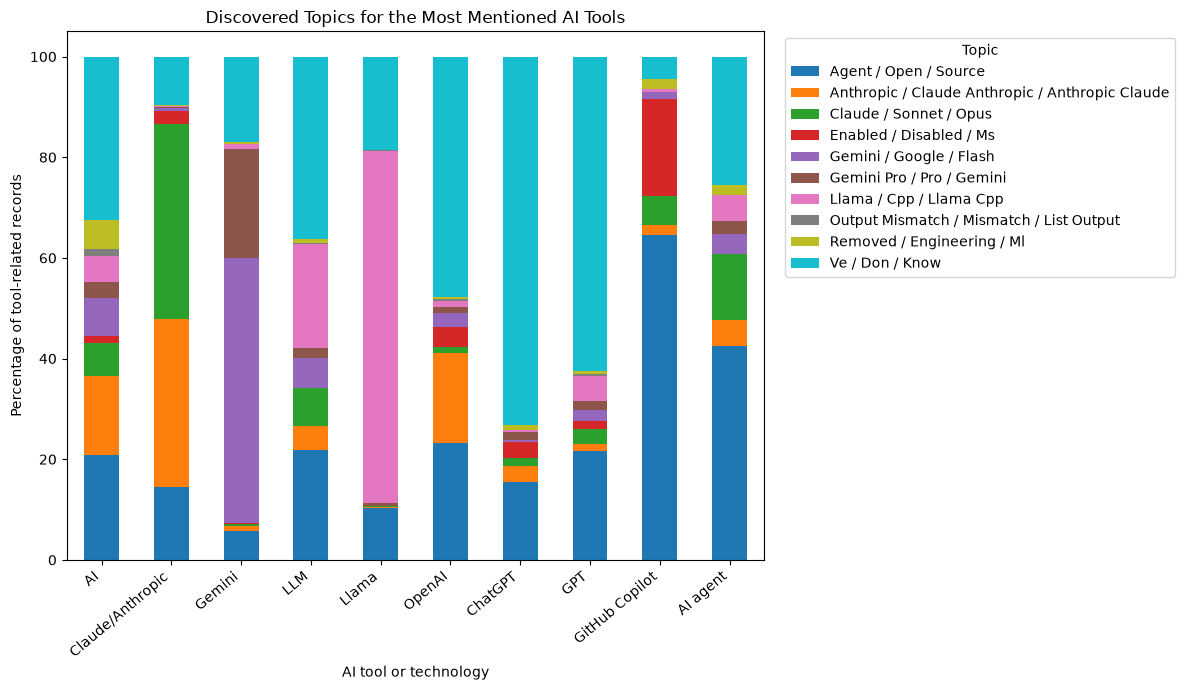

In [23]:
tool_topic_data = (
    df[
        [
            "record_id",
            "ai_tools",
            "topic_name",
        ]
    ]
    .explode("ai_tools")
    .reset_index(drop=True)
)

tool_topic_data[
    "ai_tools"
] = (
    tool_topic_data[
        "ai_tools"
    ]
    .replace("", np.nan)
)

tool_topic_data = (
    tool_topic_data
    .dropna(
        subset=["ai_tools"]
    )
)

if tool_topic_data.empty:
    topics_by_tool_counts = pd.DataFrame()
    topics_by_tool_percent = pd.DataFrame()
    print("No AI-tool values are available.")
else:
    topics_by_tool_counts = (
        tool_topic_data
        .groupby(
            [
                "ai_tools",
                "topic_name",
            ]
        )
        .size()
        .unstack(fill_value=0)
    )

    tool_totals = (
        topics_by_tool_counts
        .sum(axis=1)
        .replace(0, np.nan)
    )

    topics_by_tool_percent = (
        topics_by_tool_counts
        .div(tool_totals, axis=0)
        .mul(100)
        .fillna(0)
        .round(2)
    )

    topics_by_tool_counts.to_csv(
        RESULTS_DIR
        / "topics_by_ai_tool_counts.csv"
    )

    topics_by_tool_percent.to_csv(
        RESULTS_DIR
        / "topics_by_ai_tool_percent.csv"
    )

    top_tools = (
        topics_by_tool_counts
        .sum(axis=1)
        .sort_values(
            ascending=False
        )
        .head(10)
        .index
    )

    display(
        topics_by_tool_percent.loc[
            top_tools
        ]
    )

    plt.figure(figsize=(12, 7))

    topics_by_tool_percent.loc[
        top_tools
    ].plot(
        kind="bar",
        stacked=True,
        ax=plt.gca(),
    )

    plt.title(
        "Discovered Topics for the Most Mentioned AI Tools"
    )
    plt.xlabel("AI tool or technology")
    plt.ylabel(
        "Percentage of tool-related records"
    )
    plt.xticks(rotation=40, ha="right")
    plt.legend(
        title="Topic",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / "topics_by_ai_tool.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 22. Sentiment by topic


selected_sentiment_label,Negative,Neutral,Positive
topic_name,,,
Agent / Open / Source,69,384,73
Anthropic / Claude Anthropic / Anthropic Claude,49,166,32
Claude / Sonnet / Opus,43,160,68
Enabled / Disabled / Ms,13,36,2
Gemini / Google / Flash,40,168,67
Gemini Pro / Pro / Gemini,12,81,24
Llama / Cpp / Llama Cpp,51,203,80
Output Mismatch / Mismatch / List Output,3,14,0
Removed / Engineering / Ml,11,51,6


selected_sentiment_label,Negative,Neutral,Positive
topic_name,,,
Agent / Open / Source,13.12,73.00,13.88
Anthropic / Claude Anthropic / Anthropic Claude,19.84,67.21,12.96
Claude / Sonnet / Opus,15.87,59.04,25.09
Enabled / Disabled / Ms,25.49,70.59,3.92
Gemini / Google / Flash,14.55,61.09,24.36
Gemini Pro / Pro / Gemini,10.26,69.23,20.51
Llama / Cpp / Llama Cpp,15.27,60.78,23.95
Output Mismatch / Mismatch / List Output,17.65,82.35,0.00
Removed / Engineering / Ml,16.18,75.00,8.82


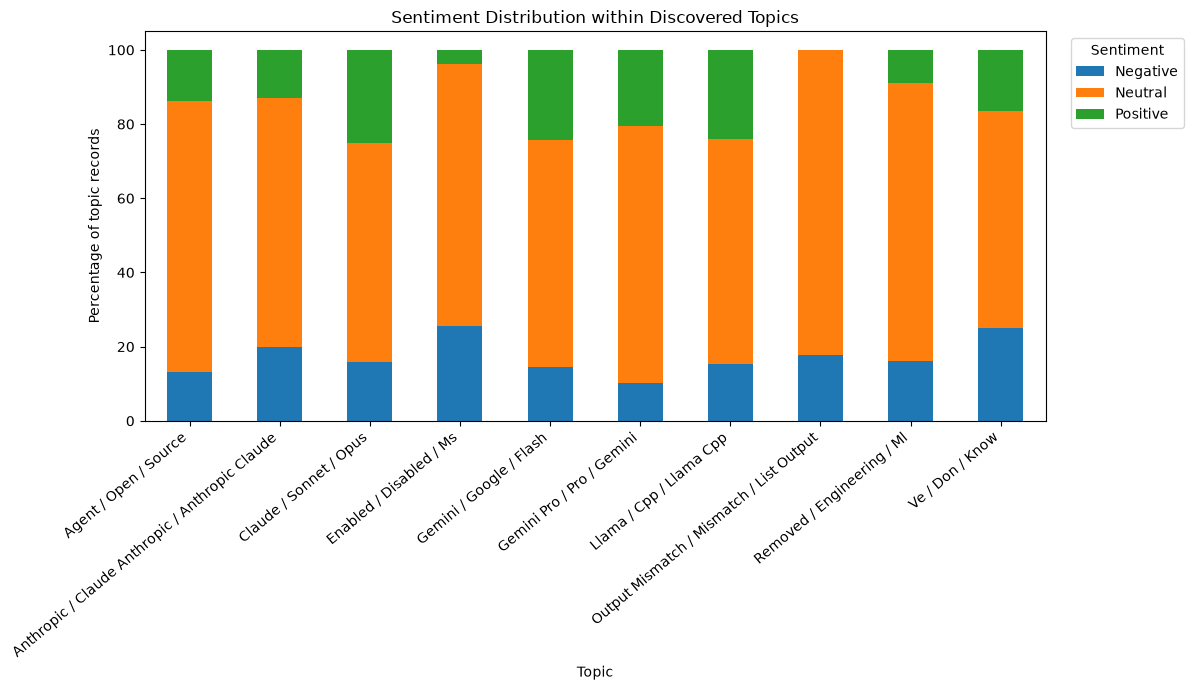

In [24]:
sentiment_by_topic_counts = (
    df.groupby(
        [
            "topic_name",
            "selected_sentiment_label",
        ]
    )
    .size()
    .unstack(fill_value=0)
)

topic_totals = (
    sentiment_by_topic_counts
    .sum(axis=1)
    .replace(0, np.nan)
)

sentiment_by_topic_percent = (
    sentiment_by_topic_counts
    .div(topic_totals, axis=0)
    .mul(100)
    .fillna(0)
    .round(2)
)

display(sentiment_by_topic_counts)
display(sentiment_by_topic_percent)

sentiment_by_topic_counts.to_csv(
    RESULTS_DIR
    / "sentiment_by_topic_counts.csv"
)

sentiment_by_topic_percent.to_csv(
    RESULTS_DIR
    / "sentiment_by_topic_percent.csv"
)

plt.figure(figsize=(12, 7))

sentiment_by_topic_percent.plot(
    kind="bar",
    stacked=True,
    ax=plt.gca(),
)

plt.title("Sentiment Distribution within Discovered Topics")
plt.xlabel("Topic")
plt.ylabel("Percentage of topic records")
plt.xticks(rotation=40, ha="right")
plt.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "sentiment_by_topic.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 23. Stress direction by topic


stress_direction,Increased stress or distress,Mixed or ambiguous,No clear stress signal,Reduced stress or relief
topic_name,,,,
Agent / Open / Source,73,0,452,1
Anthropic / Claude Anthropic / Anthropic Claude,20,0,227,0
Claude / Sonnet / Opus,27,0,244,0
Enabled / Disabled / Ms,9,0,42,0
Gemini / Google / Flash,21,1,253,0
Gemini Pro / Pro / Gemini,10,0,107,0
Llama / Cpp / Llama Cpp,43,0,291,0
Output Mismatch / Mismatch / List Output,1,0,16,0
Removed / Engineering / Ml,8,0,60,0


stress_direction,Increased stress or distress,Mixed or ambiguous,No clear stress signal,Reduced stress or relief
topic_name,,,,
Agent / Open / Source,13.88,0.00,85.93,0.19
Anthropic / Claude Anthropic / Anthropic Claude,8.10,0.00,91.90,0.00
Claude / Sonnet / Opus,9.96,0.00,90.04,0.00
Enabled / Disabled / Ms,17.65,0.00,82.35,0.00
Gemini / Google / Flash,7.64,0.36,92.00,0.00
Gemini Pro / Pro / Gemini,8.55,0.00,91.45,0.00
Llama / Cpp / Llama Cpp,12.87,0.00,87.13,0.00
Output Mismatch / Mismatch / List Output,5.88,0.00,94.12,0.00
Removed / Engineering / Ml,11.76,0.00,88.24,0.00


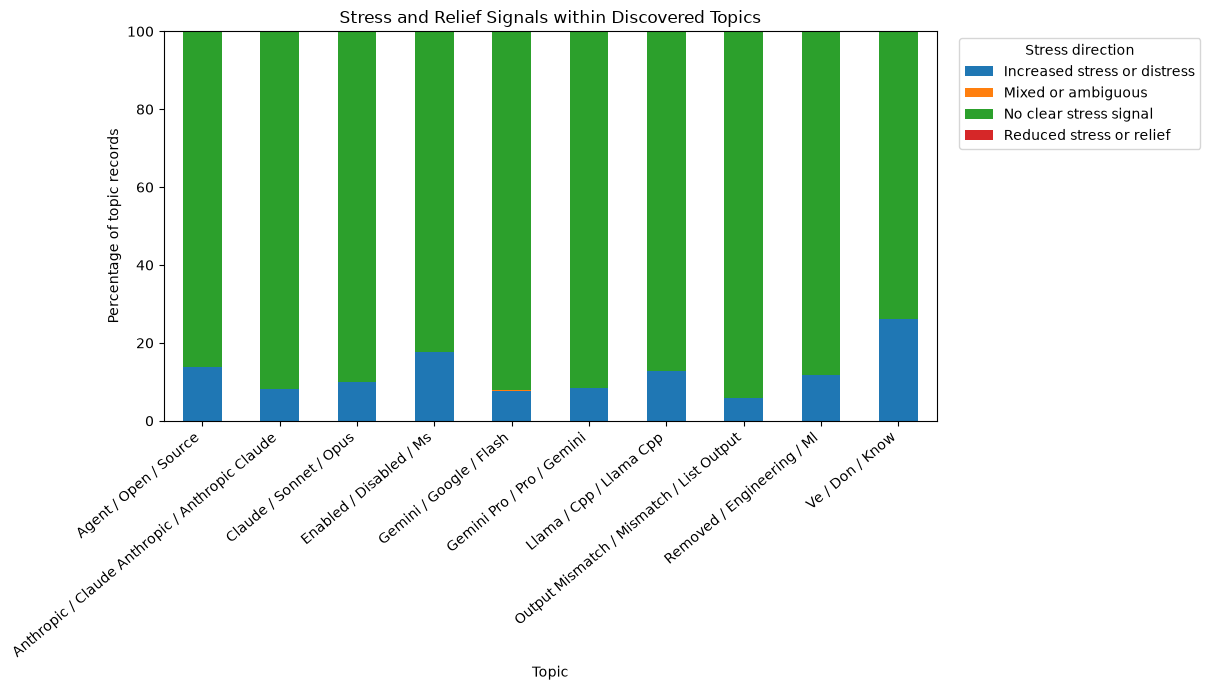

In [25]:
stress_by_topic_counts = (
    df.groupby(
        [
            "topic_name",
            "stress_direction",
        ]
    )
    .size()
    .unstack(fill_value=0)
)

stress_topic_totals = (
    stress_by_topic_counts
    .sum(axis=1)
    .replace(0, np.nan)
)

stress_by_topic_percent = (
    stress_by_topic_counts
    .div(
        stress_topic_totals,
        axis=0,
    )
    .mul(100)
    .fillna(0)
    .round(2)
)

display(stress_by_topic_counts)
display(stress_by_topic_percent)

stress_by_topic_counts.to_csv(
    RESULTS_DIR
    / "stress_by_topic_counts.csv"
)

stress_by_topic_percent.to_csv(
    RESULTS_DIR
    / "stress_by_topic_percent.csv"
)

plt.figure(figsize=(12, 7))

stress_by_topic_percent.plot(
    kind="bar",
    stacked=True,
    ax=plt.gca(),
)

plt.title("Stress and Relief Signals within Discovered Topics")
plt.xlabel("Topic")
plt.ylabel("Percentage of topic records")
plt.xticks(rotation=40, ha="right")
plt.legend(
    title="Stress direction",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "stress_by_topic.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 24. Primary emotion by topic


In [26]:
emotion_by_topic_counts = (
    df.groupby(
        [
            "topic_name",
            "primary_emotion",
        ]
    )
    .size()
    .unstack(fill_value=0)
)

emotion_topic_totals = (
    emotion_by_topic_counts
    .sum(axis=1)
    .replace(0, np.nan)
)

emotion_by_topic_percent = (
    emotion_by_topic_counts
    .div(
        emotion_topic_totals,
        axis=0,
    )
    .mul(100)
    .fillna(0)
    .round(2)
)

display(emotion_by_topic_percent)

emotion_by_topic_counts.to_csv(
    RESULTS_DIR
    / "emotion_by_topic_counts.csv"
)

emotion_by_topic_percent.to_csv(
    RESULTS_DIR
    / "emotion_by_topic_percent.csv"
)


primary_emotion,Burnout or exhaustion,Distrust or uncertainty,Frustration,Job insecurity or fear,No clear emotion,Relief or reduced stress,Stress or anxiety
topic_name,,,,,,,
Agent / Open / Source,1.14,3.99,5.89,0.19,85.93,0.19,2.66
Anthropic / Claude Anthropic / Anthropic Claude,0.00,4.45,0.00,1.62,91.90,0.00,2.02
Claude / Sonnet / Opus,0.74,4.80,3.32,0.00,90.04,0.00,1.11
Enabled / Disabled / Ms,0.00,3.92,13.73,0.00,82.35,0.00,0.00
Gemini / Google / Flash,0.36,2.18,4.36,0.36,92.00,0.00,0.73
Gemini Pro / Pro / Gemini,0.00,3.42,3.42,0.00,91.45,0.00,1.71
Llama / Cpp / Llama Cpp,0.90,3.89,5.69,0.00,87.13,0.00,2.40
Output Mismatch / Mismatch / List Output,0.00,0.00,5.88,0.00,94.12,0.00,0.00
Removed / Engineering / Ml,2.94,0.00,2.94,1.47,88.24,0.00,4.41


## 25. Topics over time

Only records with valid dates are used.


topic_name,Agent / Open / Source,Anthropic / Claude Anthropic / Anthropic Claude,Claude / Sonnet / Opus,Enabled / Disabled / Ms,Gemini / Google / Flash,Gemini Pro / Pro / Gemini,Llama / Cpp / Llama Cpp,Output Mismatch / Mismatch / List Output,Removed / Engineering / Ml,Ve / Don / Know
month,,,,,,,,,,
2025-08,11.48,3.35,11.24,0.00,13.40,4.55,17.70,0.24,0.00,38.04
2025-09,13.56,7.46,15.93,0.34,13.56,3.05,16.61,0.34,0.00,29.15
2025-10,11.32,6.13,10.85,0.94,13.68,8.49,20.75,0.47,0.00,27.36
2025-11,50.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00
2025-12,66.67,0.00,0.00,33.33,0.00,0.00,0.00,0.00,0.00,0.00
2026-01,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-02,80.00,0.00,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-03,63.64,0.00,0.00,9.09,0.00,0.00,0.00,0.00,0.00,27.27
2026-04,88.89,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11.11


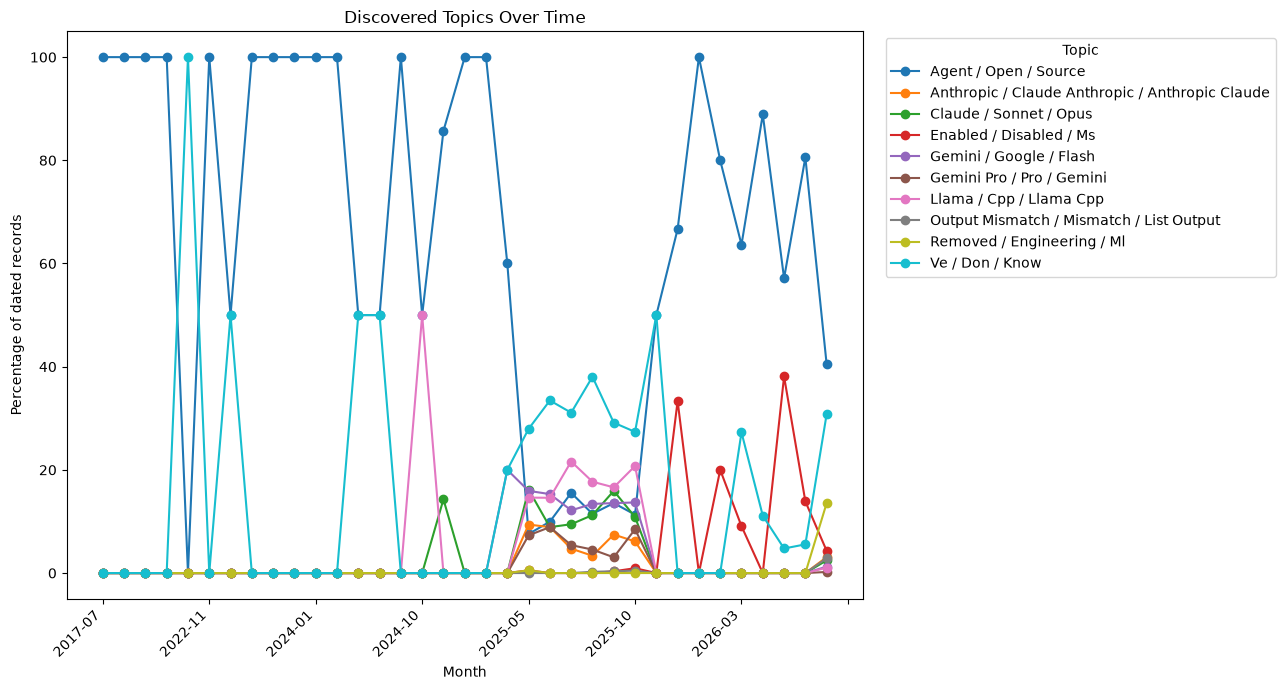

In [27]:
dated_df = (
    df.dropna(
        subset=["created_at_utc"]
    )
    .copy()
)

if dated_df.empty:
    topics_over_time_counts = pd.DataFrame()
    topics_over_time_percent = pd.DataFrame()
    print("No dated records are available.")
else:
    dated_df["month"] = (
        dated_df[
            "created_at_utc"
        ]
        .dt.strftime("%Y-%m")
    )

    topics_over_time_counts = (
        dated_df
        .groupby(
            [
                "month",
                "topic_name",
            ]
        )
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    month_totals = (
        topics_over_time_counts
        .sum(axis=1)
        .replace(0, np.nan)
    )

    topics_over_time_percent = (
        topics_over_time_counts
        .div(
            month_totals,
            axis=0,
        )
        .mul(100)
        .fillna(0)
        .round(2)
    )

    topics_over_time_counts.to_csv(
        RESULTS_DIR
        / "topics_over_time_counts.csv"
    )

    topics_over_time_percent.to_csv(
        RESULTS_DIR
        / "topics_over_time_percent.csv"
    )

    display(
        topics_over_time_percent.tail(12)
    )

    plt.figure(figsize=(13, 7))

    topics_over_time_percent.plot(
        ax=plt.gca(),
        marker="o",
    )

    plt.title("Discovered Topics Over Time")
    plt.xlabel("Month")
    plt.ylabel(
        "Percentage of dated records"
    )
    plt.xticks(rotation=45, ha="right")
    plt.legend(
        title="Topic",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / "topics_over_time.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 26. Inspect low-confidence topic assignments

Low-confidence records may discuss several subjects or may not fit any topic
cleanly.


In [28]:
low_confidence_columns = [
    column for column in [
        "record_id",
        "platform",
        "text_clean_basic",
        "topic_name",
        "topic_confidence",
        "selected_sentiment_label",
        "stress_direction",
        "primary_emotion",
    ]
    if column in df.columns
]

low_confidence_topics = (
    df.nsmallest(
        30,
        "topic_confidence",
    )[
        low_confidence_columns
    ]
)

display(low_confidence_topics)

low_confidence_topics.to_csv(
    RESULTS_DIR
    / "low_confidence_topic_assignments.csv",
    index=False,
)


,record_id,platform,text_clean_basic,topic_name,topic_confidence,selected_sentiment_label,stress_direction,primary_emotion
499,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,OpenAI is partnering with Johnny Ives,Ve / Don / Know,0.000000,Neutral,No clear stress signal,No clear emotion
682,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,It's Here GPT-5,Ve / Don / Know,0.000000,Neutral,No clear stress signal,No clear emotion
729,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,TIL ChatGPT is also constipated,Ve / Don / Know,0.000000,Negative,No clear stress signal,No clear emotion
877,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,AMD stock skyrockets 25% as OpenAI looks to ta...,Enabled / Disabled / Ms,0.209794,Positive,No clear stress signal,No clear emotion
668,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Aggregated Benchmark Comparison between gpt-os...,Llama / Cpp / Llama Cpp,0.216832,Neutral,No clear stress signal,No clear emotion
2137,hackernews::48996196,Hacker News,Jim Cramer worried about security implications...,Removed / Engineering / Ml,0.224075,Neutral,Increased stress or distress,Stress or anxiety
80,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Dario Amodei speaks out against Trump's bill b...,Anthropic / Claude Anthropic / Anthropic Claude,0.228023,Negative,No clear stress signal,No clear emotion
159,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Material Requirements for 8 Billion Humanoid R...,Ve / Don / Know,0.231115,Neutral,No clear stress signal,No clear emotion
882,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,NVIDIA DGX Spark in the wild in a OpenAI confe...,Llama / Cpp / Llama Cpp,0.235068,Neutral,No clear stress signal,No clear emotion
661,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,gpt-oss-120b outperforms DeepSeek-R1-0528 in b...,Llama / Cpp / Llama Cpp,0.257121,Neutral,No clear stress signal,No clear emotion


## 27. Save the enriched topic-assignment dataset


In [29]:
def json_safe_copy(dataframe):
    output = dataframe.copy()

    if "created_at_utc" in output.columns:
        output[
            "created_at_utc"
        ] = (
            output[
                "created_at_utc"
            ]
            .map(
                lambda value:
                value.isoformat()
                if pd.notna(value)
                else None
            )
        )

    return output


def csv_safe_copy(dataframe):
    output = dataframe.copy()

    list_columns = [
        "ai_tools",
        "research_themes",
        "detected_emotions",
        "stress_causes",
        "stress_evidence",
    ]

    for column in list_columns:
        if column in output.columns:
            output[column] = (
                output[column]
                .map(
                    lambda value:
                    json.dumps(
                        value,
                        ensure_ascii=False,
                    )
                    if isinstance(
                        value,
                        list,
                    )
                    else value
                )
            )

    return output


json_output = json_safe_copy(df)
csv_output = csv_safe_copy(df)

TOPIC_JSONL_PATH = (
    RESULTS_DIR
    / "topic_assignments.jsonl"
)

TOPIC_CSV_PATH = (
    RESULTS_DIR
    / "topic_assignments.csv"
)

json_output.to_json(
    TOPIC_JSONL_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

csv_output.to_csv(
    TOPIC_CSV_PATH,
    index=False,
)

print("Saved:", TOPIC_JSONL_PATH)
print("Saved:", TOPIC_CSV_PATH)


Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/topics/topic_assignments.jsonl
Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/topics/topic_assignments.csv


## 28. Automatically generated findings

Review these statements before using them in the report.


In [30]:
largest_topic = (
    topic_distribution
    .sort_values(
        "records",
        ascending=False,
    )
    .iloc[0]
)

mean_topic_confidence = float(
    df["topic_confidence"].mean()
)

findings = [
    {
        "finding": "Analyzed records",
        "value": f"{len(df):,}",
    },
    {
        "finding": "Selected number of topics",
        "value": (
            SELECTED_NUMBER_OF_TOPICS
        ),
    },
    {
        "finding": "Selection method",
        "value": selection_method,
    },
    {
        "finding": "Largest provisional topic",
        "value": (
            f"{largest_topic['topic_name']} "
            f"({largest_topic['records']:,} records; "
            f"{largest_topic['percentage']:.2f}%)"
        ),
    },
    {
        "finding": "Mean topic confidence",
        "value": (
            f"{mean_topic_confidence:.4f}"
        ),
    },
    {
        "finding": "Low-confidence assignments",
        "value": (
            f"{int(df['topic_low_confidence'].sum()):,}"
        ),
    },
]

topic_findings = pd.DataFrame(
    findings
)

display(topic_findings)

topic_findings.to_csv(
    RESULTS_DIR
    / "topic_modeling_key_findings.csv",
    index=False,
)


,finding,value
0,Analyzed records,"2,666"
1,Selected number of topics,10
2,Selection method,Highest combined reconstruction-diversity score
3,Largest provisional topic,Ve / Don / Know (760 records; 28.51%)
4,Mean topic confidence,0.6475
5,Low-confidence assignments,124


## 29. Interpretation rules

### Appropriate

> NMF discovered recurring lexical patterns that were interpreted as
> provisional discussion topics.

### Inappropriate

> The algorithm objectively proved the only true topics in developer
> discussions.

The automatic names are provisional. Final names should be assigned after
reviewing:

- top keywords;
- representative documents;
- stress and sentiment patterns;
- platform distribution.


## 30. Limitations

- Topic count selection is approximate.
- NMF topics depend on TF-IDF settings.
- Generic terms may still influence topics.
- One document receives one dominant topic even when it contains several.
- Automatic topic names are provisional.
- Low-confidence assignments may be ambiguous.
- Short or highly technical texts may be difficult to interpret.
- Topic modeling identifies lexical patterns, not causal explanations.
- The dataset does not represent all developers.


## 31. Completion checklist

This phase is complete when:

- the TF-IDF matrix is created;
- candidate topic counts are evaluated;
- the final NMF model is fitted;
- keywords are extracted;
- representative documents are reviewed;
- topic names are interpreted;
- every record receives a topic assignment;
- topic comparisons are generated;
- figures and CSV files are saved;
- limitations are documented.

The next technical phase is:

> **08 — Dashboard and Final Reporting**


In [31]:
print("Topic modeling completed.")

print("\nGenerated result files:")
for path in sorted(
    RESULTS_DIR.glob("*")
):
    if path.is_file():
        print("-", path.name)

print("\nGenerated figure files:")
for path in sorted(
    FIGURE_DIR.glob("*.png")
):
    print("-", path.name)


Topic modeling completed.

Generated result files:
- emotion_by_topic_counts.csv
- emotion_by_topic_percent.csv
- low_confidence_topic_assignments.csv
- provisional_topic_names.csv
- sentiment_by_topic_counts.csv
- sentiment_by_topic_percent.csv
- stress_by_topic_counts.csv
- stress_by_topic_percent.csv
- top_global_tfidf_features.csv
- topic_assignments.csv
- topic_assignments.jsonl
- topic_count_evaluation.csv
- topic_distribution.csv
- topic_keywords.csv
- topic_modeling_key_findings.csv
- topic_representative_documents.csv
- topic_summary.csv
- topic_validation.csv
- topics_by_ai_tool_counts.csv
- topics_by_ai_tool_percent.csv
- topics_by_platform_counts.csv
- topics_by_platform_percent.csv
- topics_over_time_counts.csv
- topics_over_time_percent.csv

Generated figure files:
- sentiment_by_topic.png
- stress_by_topic.png
- topic_count_combined_score.png
- topic_count_diversity.png
- topic_count_reconstruction_error.png
- topic_distribution.png
- topics_by_ai_tool.png
- topics_by_pl